# Initial Analysis

In [15]:
import Ocean_Opt_Algorithm as OOA
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import importlib

importlib.reload(OOA)

<module 'Ocean_Opt_Algorithm' from 'C:\\Users\\sebas\\PycharmProjects\\Advanced-Lab-Code\\Ocean_Optics_Specto\\Ocean_Opt_Algorithm.py'>

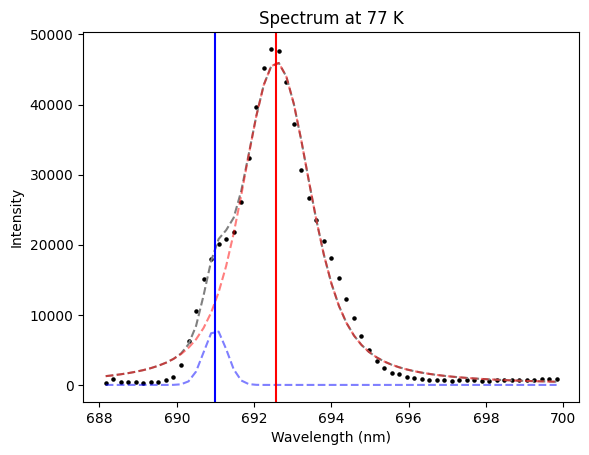

----- Results (77 K) -----
R1 Theory: 693.4
R1 Obs: 692.5770528592866 ± 0.09470124542493077
R1 frac: 0.9561655408347849
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.07013954160149793
R2 frac: 0.043834459165215015
Reduced Chi Squared: 516.8066042981626


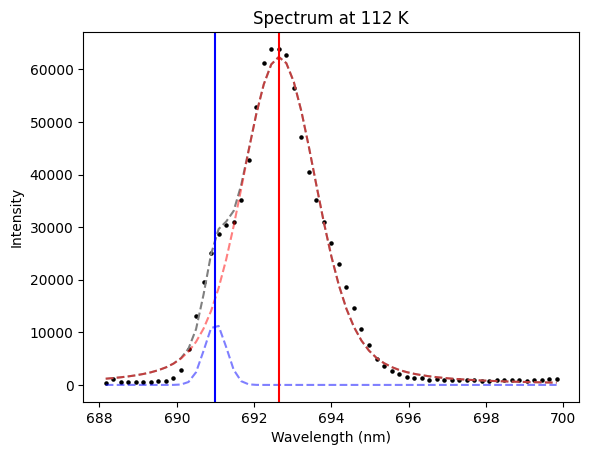

----- Results (112 K) -----
R1 Theory: 693.4
R1 Obs: 692.6482658118451 ± 0.06989988764691422
R1 frac: 0.9548270687973247
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.05088527740726955
R2 frac: 0.04517293120267536
Reduced Chi Squared: 474.732005097061


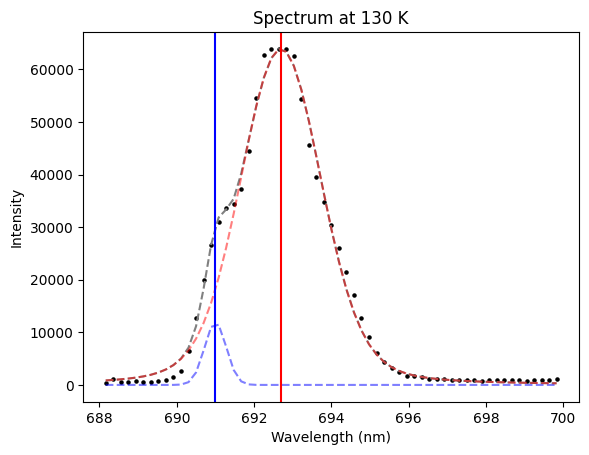

----- Results (130 K) -----
R1 Theory: 693.4
R1 Obs: 692.6930765917215 ± 0.05627788869324628
R1 frac: 0.9564411717221442
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.04034619700306205
R2 frac: 0.04355882827785587
Reduced Chi Squared: 383.45889548880825


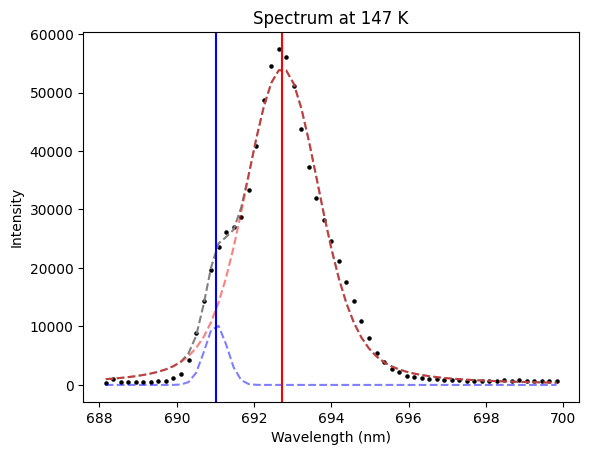

----- Results (147 K) -----
R1 Theory: 693.4
R1 Obs: 692.7312227942851 ± 0.06925591930435457
R1 frac: 0.9528139983670186
R2 Theory: 692.9
R2 Obs: 691.0176490786631 ± 0.05026943770663004
R2 frac: 0.04718600163298128
Reduced Chi Squared: 345.82782518309796


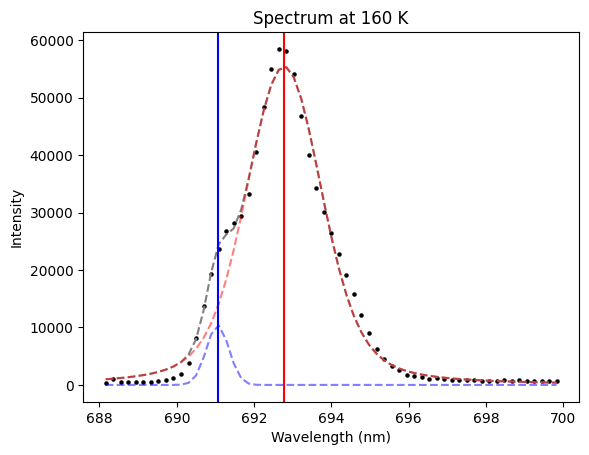

----- Results (160 K) -----
R1 Theory: 693.4
R1 Obs: 692.7749464154898 ± 0.06873988909397873
R1 frac: 0.9537452426171288
R2 Theory: 692.9
R2 Obs: 691.0580259517895 ± 0.04999707372661655
R2 frac: 0.04625475738287114
Reduced Chi Squared: 325.5842131839094


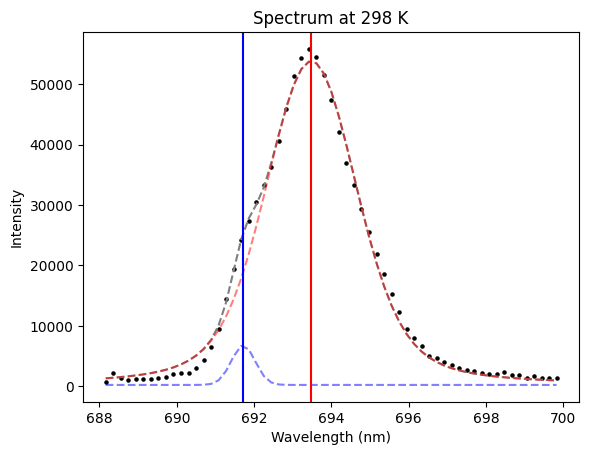

----- Results (298 K) -----
R1 Theory: 693.4
R1 Obs: 693.4803603266727 ± 0.0749828538820013
R1 frac: 0.9731812426014268
R2 Theory: 692.9
R2 Obs: 691.7198296882833 ± 0.05539007831232963
R2 frac: 0.026818757398573142
Reduced Chi Squared: 206.17781154453448


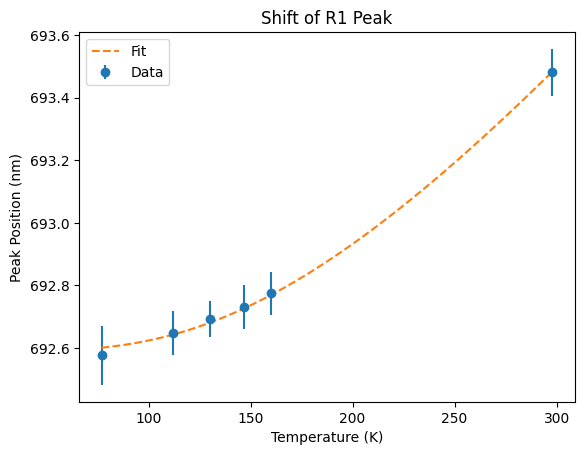

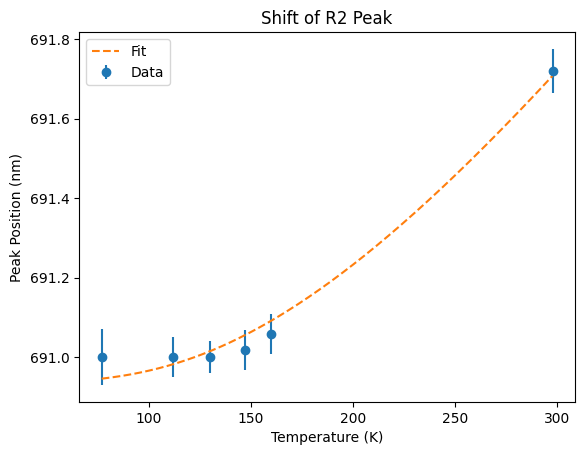

In [16]:
column_names = [
    ["W_77","I_77"],
    ["W_112","I_112"],
    ["W_130","I_130"],
    ["W_147","I_147"],
    ["W_160","I_160"],
    ["W_298","I_298"]
]

center1_guesses = {
    77: 691,
    112: 691,
    130: 691,
    147: 691,
    160: 691,
    298: 692
}

results = OOA.analyze_ruby_spectra(
    "Ocean_Opt_test.xlsx",
    column_names,
    center1_guesses=center1_guesses,
    Td_fixed_input=760
)

# Calculations

In [32]:
#Linewidth function
def voigt_FWHM(sigma, gamma):
    gamma_L = 2*sigma
    gamma_G = 2*np.sqrt(2*np.log(2))*gamma
    return 0.5346*gamma_L + np.sqrt(0.2166*gamma_L**2+gamma_G**2)

from scipy.integrate import quad
Td_fixed = 760
def debye_integrand(x):
    return x**3 / (np.exp(x) - 1)

def debye_integral(T, Td):

    if T <= 0:
        return 0  # avoid divide by zero

    upper = min(Td/T, 50)

    result, _ = quad(
        lambda x: x**3/(np.exp(x)-1),
        0,
        upper
    )

    return result

def ruby_shift_model(T, R0, alpha, Td):
    integral_vals = np.array([debye_integral(t, Td) for t in T])
    return R0 + alpha * (T / Td)**4 * integral_vals

def ruby_shift_model_fixed(T, R0, alpha):
    integral_vals = np.array([debye_integral(t, Td_fixed) for t in T])
    return R0 + alpha * (T / Td_fixed)**4 * integral_vals

In [72]:
temperatures = np.array([77, 112, 130, 147, 160, 298])

temperatures = np.array([77, 112, 130, 147, 160, 298])

# Observed peak positions
R1_values = np.array([results[T]["R1_obs"] for T in temperatures])
R1_errs   = np.array([results[T]["R1_err"] for T in temperatures])

R2_values = np.array([results[T]["R2_obs"] for T in temperatures])
R2_errs   = np.array([results[T]["R2_err"] for T in temperatures])


# Voigt parameters
R1_sigma = np.array([results[T]["parameters"][3] for T in temperatures])
R1_sigma_errs = np.array([np.sqrt(results[T]["covariance"][3][3]) for T in temperatures])

R1_gammas = np.array([results[T]["parameters"][2] for T in temperatures])
R1_gamma_errs = np.array([np.sqrt(results[T]["covariance"][2][2]) for T in temperatures])


R2_sigma = np.array([results[T]["parameters"][7] for T in temperatures])
R2_sigma_errs = np.array([np.sqrt(results[T]["covariance"][7][7]) for T in temperatures])

R2_gammas = np.array([results[T]["parameters"][6] for T in temperatures])
R2_gamma_errs = np.array([np.sqrt(results[T]["covariance"][6][6]) for T in temperatures])


# Line shifts
R1_shift = R1_values[-1] - R1_values
R1_shift_err = np.sqrt(R1_errs[-1]**2 + R1_errs**2)

R2_shift = R2_values[-1] - R2_values
R2_shift_err = np.sqrt(R2_errs[-1]**2 + R2_errs**2)


# Linewidths
R1_linewidth = voigt_FWHM(R1_sigma, R1_gammas)
R1_linewidth_err = np.sqrt(
    (voigt_FWHM(R1_sigma + R1_sigma_errs, R1_gammas) - R1_linewidth)**2 +
    (voigt_FWHM(R1_sigma, R1_gammas + R1_gamma_errs) - R1_linewidth)**2
)

R2_linewidth = voigt_FWHM(R2_sigma, R2_gammas)
R2_linewidth_err = np.sqrt(
    (voigt_FWHM(R2_sigma + R2_sigma_errs, R2_gammas) - R2_linewidth)**2 +
    (voigt_FWHM(R2_sigma, R2_gammas + R2_gamma_errs) - R2_linewidth)**2
)

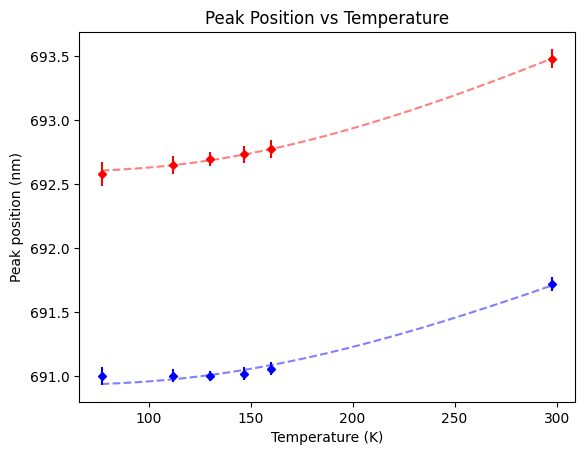

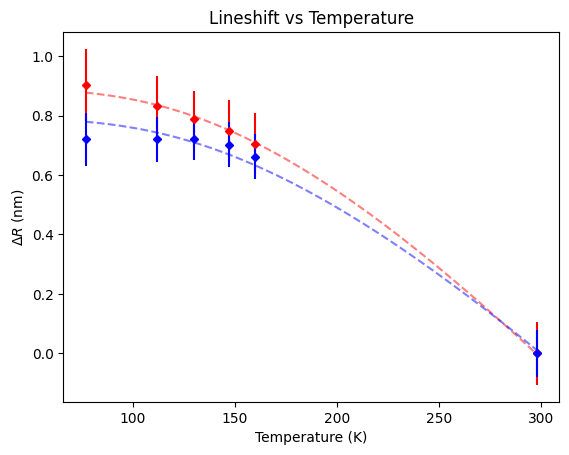

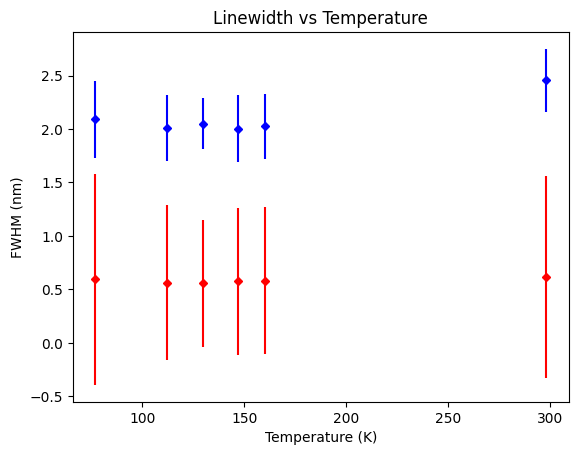

In [73]:
T_plot = np.arange(temperatures[0], temperatures[-1], 0.01)
#---------------------------------------------
p0_R1_pos = [R1_values[0], 1]

pop_R1_pos, cov_R1_pos = curve_fit(ruby_shift_model_fixed,
                           temperatures,
                           R1_values,
                           sigma=R1_errs,
                           absolute_sigma=True,
                           p0 = p0_R1_pos)

p0_R2_pos = [R2_values[0], 1]

pop_R2_pos, cov_R2_pos = curve_fit(ruby_shift_model_fixed,
                           temperatures,
                           R2_values,
                           sigma=R2_errs,
                           absolute_sigma=True,
                           p0 = p0_R2_pos)
#----------------------------------------------

p0_R1_shift = [R1_shift[0], 1]

pop_R1_shift, cov_R1_shift = curve_fit(ruby_shift_model_fixed,
                           temperatures,
                           R1_shift,
                           sigma=R1_shift_err,
                           absolute_sigma=True,
                           p0 = p0_R1_shift)

p0_R2_shift = [R2_shift[0], 1]

pop_R2_shift, cov_R2_shift = curve_fit(ruby_shift_model_fixed,
                           temperatures,
                           R2_shift,
                           sigma=R2_shift_err,
                           absolute_sigma=True,
                           p0 = p0_R2_shift)
#--------------------------------------------------






plt.figure(1)
plt.errorbar(temperatures, R1_values, yerr=R1_errs, color = "red", markersize = 4, marker = "D", linestyle = "None")
plt.plot(T_plot, ruby_shift_model_fixed(T_plot, *pop_R1_pos), color = "red", linestyle = "--", alpha = 0.5)

plt.errorbar(temperatures, R2_values, yerr=R2_errs, color = "blue", markersize = 4, marker = "D", linestyle = "None")
plt.plot(T_plot, ruby_shift_model_fixed(T_plot, *pop_R2_pos), color = "blue", linestyle = "--", alpha = 0.5)

plt.xlabel("Temperature (K)")
plt.ylabel("Peak position (nm)")
plt.title("Peak Position vs Temperature")
plt.show()

plt.figure(1)
plt.errorbar(temperatures, R1_shift, yerr = R1_shift_err, color = "red", markersize = 4, marker = "D", linestyle = "None")
plt.plot(T_plot, ruby_shift_model_fixed(T_plot, *pop_R1_shift), color = "red", linestyle = "--", alpha = 0.5)
plt.errorbar(temperatures, R2_shift, yerr= R2_shift_err, color = "blue", markersize = 4, marker = "D", linestyle = "None")
plt.plot(T_plot, ruby_shift_model_fixed(T_plot, *pop_R2_shift), color = "blue", linestyle = "--", alpha = 0.5)

plt.xlabel("Temperature (K)")
plt.ylabel(rf"$\Delta R$ (nm)")
plt.title("Lineshift vs Temperature")
plt.show()

plt.figure(1)
plt.errorbar(temperatures, R1_linewidth, yerr= R1_linewidth_err, color = "red", markersize = 4, marker = "D", linestyle = "None")
plt.errorbar(temperatures, R2_linewidth, yerr= R2_linewidth_err, color = "blue", markersize = 4, marker = "D", linestyle = "None")

plt.xlabel("Temperature (K)")
plt.ylabel("FWHM (nm)")
plt.title("Linewidth vs Temperature")
plt.show()

# Main Lineshift plot

In [145]:
residual_R1_lineshift = (R1_values - ruby_shift_model_fixed(temperatures, *pop_R1_pos))/R1_errs
residual_R2_lineshift = (R2_values - ruby_shift_model_fixed(temperatures, *pop_R2_pos))/R2_errs

lag_R1_i = residual_R1_lineshift[1:]
lag_R1_i_minus1 = residual_R1_lineshift[0:-1]

lag_R2_i = residual_R2_lineshift[1:]
lag_R2_i_minus1 = residual_R2_lineshift[0:-1]

In [146]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch

scalefactor = 10

red_cb = "#e41a1c"
blue_cb = "#377eb8"

marker_shapes = ["^","v"]
marker_colours = [red_cb, blue_cb]

y_data = [R1_values*scalefactor, R2_values*scalefactor]
y_errors = [R1_errs*scalefactor, R2_errs*scalefactor]
residuals = [residual_R1_lineshift, residual_R2_lineshift]
lineshift_pops = [pop_R1_pos, pop_R2_pos]

y_data_delta = [R1_shift*scalefactor, R2_shift*scalefactor]
y_errors_delta = [R1_shift_err*scalefactor, R2_shift_err*scalefactor]
delta_pops = [pop_R1_shift, pop_R2_shift]

y_data_linewidth = [R1_linewidth*scalefactor, R2_linewidth*scalefactor]
y_errors_linewidth = [R1_linewidth_err*scalefactor, R2_linewidth_err*scalefactor]


x_lagplot = [lag_R1_i, lag_R2_i]
y_lagplot = [lag_R1_i_minus1, lag_R2_i_minus1]

residual_band_R1 = Patch(
    facecolor=marker_colours[0],
    alpha = 0.12,
    label = r"R1 1$\sigma$ Residuals"
)
residual_band_R2 = Patch(
    facecolor=marker_colours[1],
    alpha = 0.12,
    label = r"R2 1$\sigma$ Residuals"
)

legend_elements = [
    Line2D([0], [0],
           color=red_cb,
           marker = marker_shapes[0],
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,

           label=r"R1 Position"),

    residual_band_R1,

    Line2D([0], [0],
           color=blue_cb,
           marker = marker_shapes[1],
           linestyle='-',
           markerfacecolor="none", markersize=5, linewidth=1.5,
           label=r"R2 Position"),

    residual_band_R2
]

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

laptop_savepath_lineshift = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\lineshift.png"

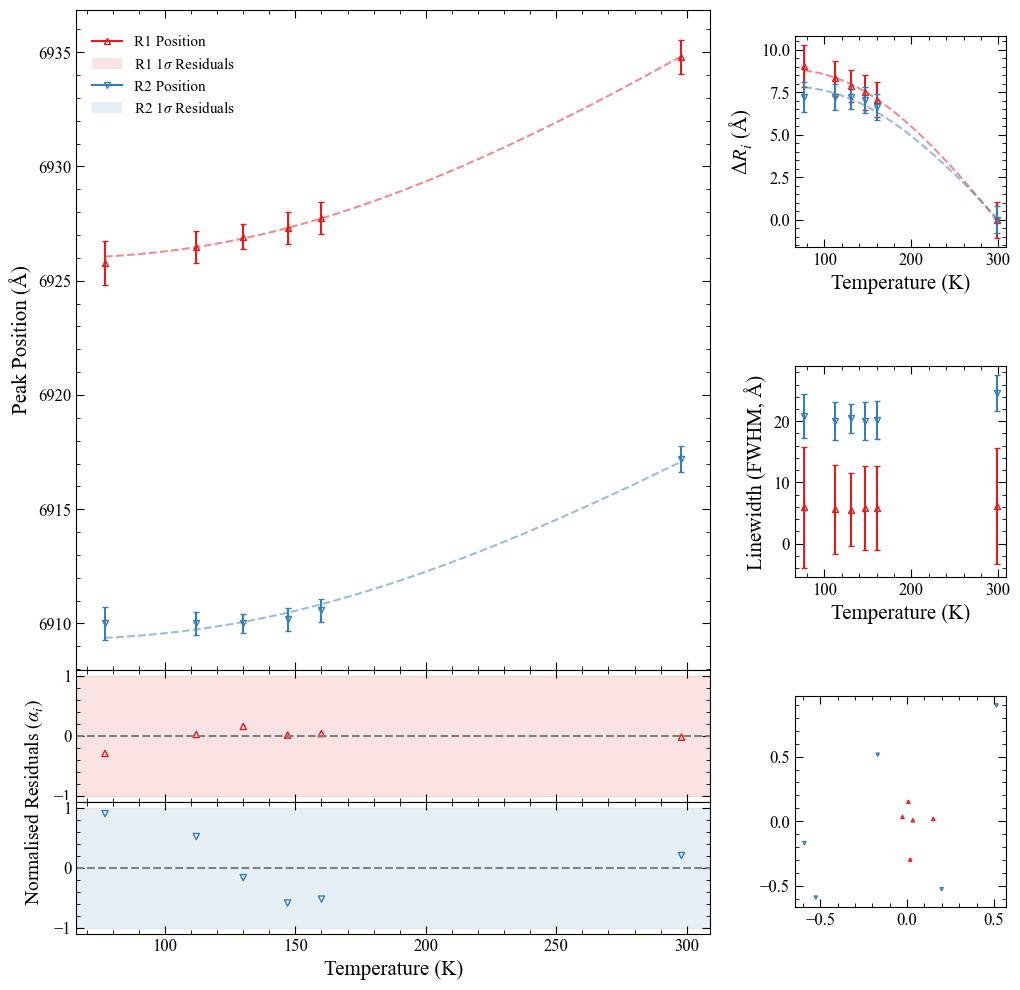

In [147]:
#configuration
fig = plt.figure(figsize = (12,12))

gs = fig.add_gridspec(
    3, 2,
    width_ratios = [4.5, 1.5],
    height_ratios = [6, 1.2, 1.2],
    wspace =0.2,
    hspace = 0.0
)

ax_main = fig.add_subplot(gs[0,0])
ax_res1 = fig.add_subplot(gs[1,0], sharex=ax_main)
ax_res2 = fig.add_subplot(gs[2,0], sharex=ax_main)

gs_side = gs[:,1].subgridspec(
    3,1,
    hspace=0.25   # spacing between squares
)

ax_side1 = fig.add_subplot(gs_side[0])
ax_side2 = fig.add_subplot(gs_side[1])
ax_side3 = fig.add_subplot(gs_side[2])

for ax in [ax_side1, ax_side2, ax_side3]:
    ax.set_box_aspect(1)

# Get positions of residual axes
pos1 = ax_res1.get_position()
pos2 = ax_res2.get_position()

# Midpoint of the gap between them
y_mid = (pos1.y0 + pos2.y1) / 2

###########

# Main Plot

###########

for data in range(len(y_data)):
    ax_main.errorbar(temperatures, y_data[data], yerr = y_errors[data],
                 color = marker_colours[data], marker = marker_shapes[data],
                 linestyle = "none", markersize = 5, markerfacecolor="none", capsize=2)

    ax_main.plot(T_plot, ruby_shift_model_fixed(T_plot, *lineshift_pops[data])*scalefactor,
                 color = marker_colours[data], linestyle = "--", alpha = 0.5)

ax_main.set_ylabel("Peak Position (Å)")

ax_main.legend(
    handles = legend_elements,
    loc = "upper left",
    bbox_to_anchor = (0.005, 0.98),
    borderpad = 0.3,
    frameon = False
)

################

# residual plots

################

for ax, data in zip([ax_res1, ax_res2], range(len(y_data))):
    ax.scatter(temperatures, residuals[data],
               marker = marker_shapes[data], color = marker_colours[data],
               s = 20, facecolor="none")

    ax.axhspan(-1,1,
               color = marker_colours[data], alpha = 0.12, zorder=0)

    ax.axhline(0, color = "grey", linestyle = "--")

ax_res2.set_xlabel("Temperature (K)")

fig.text(
    0.09, y_mid,
    r"Normalised Residuals ($\alpha_i$)",
    rotation=90,
    va='center',
    ha='center'
)


###################

# Delta R pos plot

###################

for data in range(len(y_data_delta)):
    ax_side1.errorbar(temperatures, y_data_delta[data], yerr = y_errors_delta[data],
                      color = marker_colours[data], marker = marker_shapes[data],
                      linestyle = "none", markersize = 5, markerfacecolor="none", capsize = 2)

    ax_side1.plot(T_plot, ruby_shift_model_fixed(T_plot, *delta_pops[data])*scalefactor,
                  color = marker_colours[data], linestyle = "--", alpha = 0.5)

ax_side1.set_ylabel(r"$\Delta R_i$ (Å)")
ax_side1.set_xlabel("Temperature (K)")


################

# Linewidth Plot

################

for data in range(len(y_data_linewidth)):
    ax_side2.errorbar(temperatures, y_data_linewidth[data], yerr = y_errors_linewidth[data],
                      color = marker_colours[data], marker = marker_shapes[data],
                      linestyle = "none", markersize = 5, markerfacecolor="none", capsize = 2)

ax_side2.set_ylabel(r"Linewidth (FWHM, Å)")
ax_side2.set_xlabel("Temperature (K)")

###########

# Lag Plot

###########

for data in range(len(y_lagplot)):
    ax_side3.scatter(x_lagplot[data], y_lagplot[data],
                     color = marker_colours[data], marker = marker_shapes[data],
                     s = 5, facecolor="none")


#########

# Styling

#########

for ax in [ax_main, ax_res1, ax_res2, ax_side1, ax_side2, ax_side3]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)



for ax in [ax_main, ax_res1, ax_res2, ax_side1, ax_side2, ax_side3]:
    for label in ax.get_xticklabels()+ ax.get_yticklabels():
        label.set_bbox(dict(
            facecolor="white",
            edgecolor="none",
            pad=1.0
        ))

plt.savefig(laptop_savepath_lineshift, bbox_inches='tight', dpi  = 800)
plt.show()